# marv-hyena on Colab: looking inside Evo 2

This notebook loads **Evo 2 7B** and uses [marv-hyena](https://github.com/thebnbrkr/marv-hyena) to find out
which part of the model does which job:

| type | how far it looks | Evo 2 7B blocks |
|---|---|---|
| **SE**: Hyena short explicit | 7 letters | 0 4 7 11 14 18 21 25 28 |
| **MR**: Hyena medium regularized | 128 letters | 1 5 8 12 15 19 22 26 29 |
| **LI**: Hyena long implicit | whole sequence, fading | 2 6 9 13 16 20 23 27 30 |
| **attn**: attention | whole sequence, exact lookup | 3 10 17 24 31 |

**Runtime:** `Runtime → Change runtime type → A100 GPU`, with **High-RAM** on.
An L4 may work with shorter sequences. A T4 will **not** work, because it has no bfloat16 support.
No flash-attn install is needed; see the setup cell.

**Order:** set up, run the smoke checks (they must pass), then the experiments. Each experiment tests one prediction in
[`PREDICTIONS.md`](https://github.com/thebnbrkr/marv-hyena/blob/main/PREDICTIONS.md).

## 0. Setup

In [1]:
# GPU check (no torch import yet: the install below may change the torch version)
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0


In [2]:
# OPTIONAL: keep the ~15 GB Evo 2 weights on Google Drive so the next session skips the download.
# This must run BEFORE anything imports huggingface_hub / evo2.
USE_DRIVE = False

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)
print('HF_HOME =', os.environ.get('HF_HOME', '(default ~/.cache/huggingface)'))

HF_HOME = (default ~/.cache/huggingface)


In [3]:
# Install Evo 2 + marv-hyena (~2-5 min). NO flash-attn: pip usually finds no prebuilt wheel for Colab's torch
# and compiles for hours. marv-hyena instead runs Evo 2's attention through PyTorch's built-in fused kernel
# (scaled_dot_product_attention), which is also fast on an A100 -- see marv_hyena/noflash.py.
# Colab runs Python 3.13, but every current evo2 release declares Python < 3.13, so a plain `pip install evo2`
# silently falls back to the old, incompatible 0.3.0. evo2 is pure Python, so force the current release.
# Colab also ships an empty `transformer-engine` package whose import crashes evo2; remove it (7B needs no TE).
!pip uninstall -y -q transformer-engine transformer_engine
!pip install -q --ignore-requires-python evo2==0.6.0
!rm -rf marv-hyena && git clone -q https://github.com/thebnbrkr/marv-hyena.git
!pip install -q -r marv-hyena/requirements.txt openpyxl

import sys
sys.path.insert(0, '/content/marv-hyena')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.0 MB/s eta 0:00:00


In [4]:
# Must run before anything imports evo2/vortex: lets Vortex import without flash-attn and turns flash attention off.
from marv_hyena import noflash
noflash.prepare()

import torch, vortex, evo2
from importlib.metadata import version
print('evo2', version('evo2'), '| vtx', version('vtx'))
assert version('evo2') >= '0.6.0', 'old evo2 installed: Runtime -> Disconnect and delete runtime, then rerun from the top'
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| flash-attn package installed:', noflash.flash_attn_available())
print('GPU', torch.cuda.get_device_name(0), 'capability', torch.cuda.get_device_capability(0))
assert torch.cuda.get_device_capability(0)[0] >= 8, 'needs an Ampere+ GPU with bf16 (A100 / L4 / H100)'

evo2 0.6.0 | vtx 1.1.0
torch 2.11.0+cu128 | cuda 12.8 | flash-attn package installed: False
GPU NVIDIA A100-SXM4-80GB capability (8, 0)


In [5]:
# marv-hyena's own tests (a tiny CPU model that mirrors Vortex). Should say "22 passed".
!cd marv-hyena && python -m pytest -q

......................                                                   [100%]
22 passed in 3.71s


In [6]:
# Data: the annotated E. coli K-12 genome from the evo2 repo
import os, urllib.request
os.makedirs('data', exist_ok=True)
EVO2_RAW = 'https://raw.githubusercontent.com/ArcInstitute/evo2/main/notebooks'
GENOME = 'data/NC_000913.gb'
if not os.path.exists(GENOME):
    urllib.request.urlretrieve(f'{EVO2_RAW}/sparse_autoencoder/NC_000913.gb', GENOME)

import marv_hyena as mh
from marv_hyena.probes import load_sequence
genome = load_sequence(GENOME)
print(f'E. coli genome: {len(genome):,} letters')

E. coli genome: 4,641,652 letters


In [7]:
# Load Evo 2 7B (downloads ~15 GB the first time)
import time
MODEL_NAME = 'evo2_7b'
t0 = time.time()
hm = mh.HyenaModel.load(MODEL_NAME)
print(f'loaded in {time.time()-t0:.0f}s')
print(hm.describe())
RESULTS = {}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Found complete file in repo: evo2_7b.pt


/usr/local/lib/python3.13/dist-packages/evo2/models.py:294: UserWarning: Transformer Engine not installed. Falling back to bf16 projections (use_fp8_input_projections=False). 
  warnings.warn(


  0%|          | 0/32 [00:00<?, ?it/s]

 12%|█▎        | 4/32 [00:00<00:01, 21.33it/s]

100%|██████████| 32/32 [00:00<00:00, 108.38it/s]


Extra keys in state_dict: {'blocks.15.projections._extra_state', 'blocks.31.mixer.attn._extra_state', 'blocks.10.mixer.attn._extra_state', 'blocks.19.projections._extra_state', 'blocks.6.projections._extra_state', 'blocks.31.mixer.dense._extra_state', 'blocks.2.projections._extra_state', 'blocks.18.projections._extra_state', 'blocks.17.mixer.dense._extra_state', 'blocks.26.projections._extra_state', 'blocks.3.mixer.attn._extra_state', 'blocks.20.mixer.mixer.filter.t', 'blocks.16.mixer.mixer.filter.t', 'blocks.0.projections._extra_state', 'blocks.16.projections._extra_state', 'blocks.4.projections._extra_state', 'blocks.27.mixer.mixer.filter.t', 'blocks.25.projections._extra_state', 'blocks.23.projections._extra_state', 'blocks.9.projections._extra_state', 'unembed.weight', 'blocks.8.projections._extra_state', 'blocks.10.mixer.dense._extra_state', 'blocks.3.mixer.dense._extra_state', 'blocks.30.projections._extra_state', 'blocks.11.projections._extra_state', 'blocks.29.projections._extr

## 1. Smoke checks: must pass before anything below is trusted

These check every assumption marv-hyena makes about the installed Vortex: every residual write is captured, the trace
adds up to the real logits, the distance bands rebuild each Hyena block's real output, the block-0 receptive field, and
that hooks leave no trace. If one fails, **stop**: the numbers below would mean nothing.

In [8]:
from marv_hyena.checks import run_smoke_checks
seq = genome[100_000:104_096]
ok = run_smoke_checks(hm, seq)
assert ok, 'smoke checks failed: do not trust later results; please report the output above'

[PASS] embed + sum(writes) == final residual  rel_err=8.21e-06
[PASS] trace rows sum to real logit diff  sum=+8.541 actual=+8.505
[PASS] distance bands reconstruct block 14 (se)  rel_err=3.98e-03
[PASS] distance bands reconstruct block 15 (mr)  rel_err=3.41e-03
[PASS] distance bands reconstruct block 16 (li)  rel_err=2.66e-03
[PASS] block 0 receptive field small enough to enumerate  measured 9 letters
[PASS] hooks removed after intervention  
[PASS] mean-ablating LI mixers changes the output  

8/8 checks passed


## 2. Why did the model predict this letter? (trace + distance)

`decompose_prediction` splits the model's preference for the right letter (its logit minus the mean of the other three
bases) **exactly** into what each block wrote. These are direct effects, grouped by operator type.

logit[G] - mean(other bases) @ position 2999: actual=+8.630 sum-of-rows=+8.607
  by type: attn=-0.000  embed=-0.000  li=+8.607  mlp=-0.000  mr=+0.000  se=+0.000
    L30 li   mixer     +8.607
    L29 mr   mlp       -0.000
    L29 mr   mixer     +0.000
    L28 se   mlp       +0.000
    L28 se   mixer     +0.000
    L0  se   mixer     +0.000
    L26 mr   mixer     +0.000
    L26 mr   mlp       +0.000
    embed              -0.000
    L27 li   mlp       +0.000
    L27 li   mixer     +0.000
    L25 se   mlp       +0.000


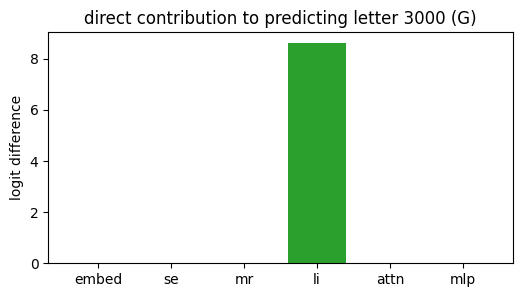

In [9]:
import matplotlib.pyplot as plt

INDEX = 3000                       # a letter inside seq to explain
d = mh.decompose_prediction(hm, seq, INDEX)
d.show(k=12)

agg = d.by_kind()
keys = [k for k in ['embed', 'se', 'mr', 'li', 'attn', 'mlp'] if k in agg]
plt.figure(figsize=(6, 3))
plt.bar(keys, [agg[k] for k in keys], color=['grey', 'C0', 'C1', 'C2', 'C3', 'C4'][:len(keys)])
plt.axhline(0, color='k', lw=0.5)
plt.title(f'direct contribution to predicting letter {INDEX} ({seq[INDEX]})')
plt.ylabel('logit difference'); plt.show()

block kind           0         1-8       9-127    128-1023  1024-16383      16384+   recon_err
    0   se      +0.000      +0.000      +0.000      +0.000      +0.000      +0.000   2.4e-03
    1   mr      +0.000      -0.000      -0.000      +0.000      +0.000      +0.000   3.4e-03
    2   li      +0.000      -0.000      -0.000      -0.000      +0.000      +0.000   2.9e-03
    4   se      +0.000      +0.000      +0.000      +0.000      +0.000      +0.000   2.8e-03
    5   mr      +0.000      -0.000      +0.000      +0.000      +0.000      +0.000   4.5e-03
    6   li      +0.000      -0.000      -0.000      +0.000      +0.000      +0.000   3.2e-03
    7   se      -0.000      -0.000      +0.000      +0.000      +0.000      +0.000   3.5e-03
    8   mr      +0.000      +0.000      +0.000      +0.000      +0.000      +0.000   3.1e-03
    9   li      +0.000      +0.000      +0.000      +0.000      -0.000      +0.000   2.8e-03
   11   se      -0.000      -0.000      +0.000      +0.000      +0.0

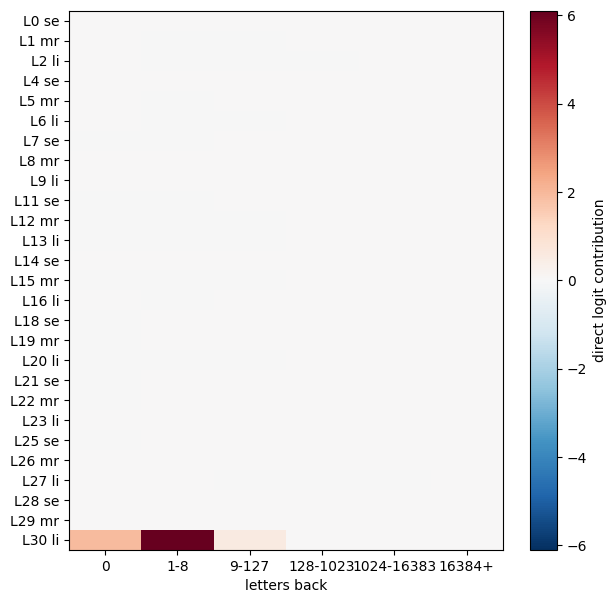

In [10]:
# How far back was each Hyena block looking when it made that push?
# Each cell = direct logit contribution coming from letters that many positions back (exact split).
import numpy as np
direction = mh.normed_direction(hm, seq, INDEX)
prof = mh.distance_profile(hm, seq[:INDEX], INDEX - 1)
mh.show_profile(prof, direction=direction)

M = np.array([r.project(direction) for r in prof])
lim = np.abs(M).max()
plt.figure(figsize=(7, 7))
plt.imshow(M, cmap='RdBu_r', vmin=-lim, vmax=lim, aspect='auto')
plt.yticks(range(len(prof)), [f'L{r.block} {r.kind}' for r in prof])
plt.xticks(range(len(prof[0].bands)), [mh.distance.band_label(b) for b in prof[0].bands])
plt.xlabel('letters back'); plt.colorbar(label='direct logit contribution'); plt.show()

## 3. How far does each Hyena block look, from the weights alone? (P4)

No forward pass. SE and MR filters are read directly. LI filters are sums of decaying exponentials, evaluated out to
1M letters. `reach99` = the distance holding 99% of the filter's weight (median over channels).

block kind   reach50   reach90   reach99     max99   (letters)
    0   se         3         6         6         6
    1   mr        24        77       121       127
    2   li         0         2         5      4528
    4   se         3         6         6         6
    5   mr        29        79       120       127
    6   li         0         3         6       463
    7   se         3         6         6         6
    8   mr        31        84       123       127
    9   li         0         3         6        80
   11   se         3         6         6         6
   12   mr        26        82       123       127
   13   li         1         3         6       100
   14   se         3         6         6         6
   15   mr        37        93       124       127
   16   li         1         3         7        49
   18   se         3         6         6         6
   19   mr        35        91       122       127
   20   li         1         3         7       324
   21   se         

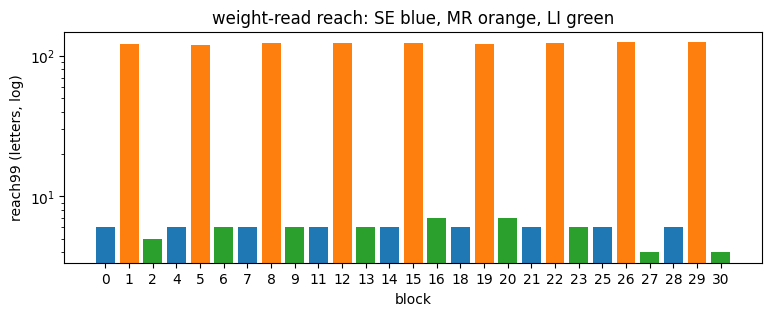

In [11]:
reach = mh.reach_table(hm)
mh.show_reach(reach)
RESULTS['reach'] = [{'block': r.block, 'kind': r.kind, 'reach50': r.reach50, 'reach90': r.reach90,
                     'reach99': r.reach99, 'max_reach99': r.max_reach99} for r in reach]

colors = {'se': 'C0', 'mr': 'C1', 'li': 'C2'}
plt.figure(figsize=(9, 3))
plt.bar([str(r.block) for r in reach], [max(r.reach99, 1) for r in reach], color=[colors[r.kind] for r in reach])
plt.yscale('log'); plt.xlabel('block'); plt.ylabel('reach99 (letters, log)')
plt.title('weight-read reach: SE blue, MR orange, LI green'); plt.show()

## 4. Who copies across long distances? (P1)

A random 200-letter insert appears twice inside real E. coli DNA, `gap` letters apart. The first copy can't be
predicted; the second can only be predicted by finding and copying the first. Each operator type's mixers are
mean-ablated in turn.

**Prediction P1:** `-attn` kills copying at gaps ≥ 1,000; `-li` barely matters. Add `50000` to `GAPS` if memory allows.

copy test: gap=100 seed=0 done
copy test: gap=100 seed=1 done
copy test: gap=1000 seed=0 done
copy test: gap=1000 seed=1 done
copy test: gap=10000 seed=0 done
copy test: gap=10000 seed=1 done


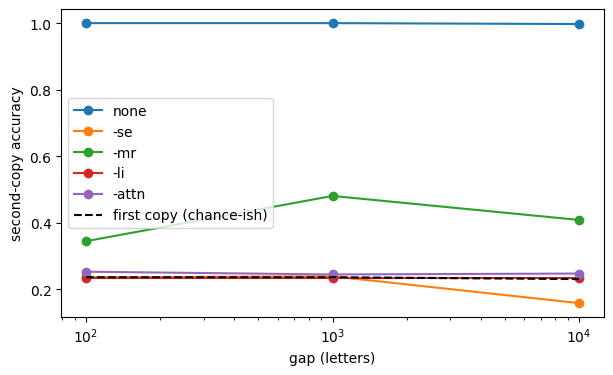

In [12]:
from marv_hyena.experiments import copy_test, summarize_copy
GAPS = (100, 1000, 10000)
copy_rows = copy_test(hm, genome, gaps=GAPS, insert_len=200, seeds=2)
RESULTS['copy_test'] = copy_rows

gaps, conds, a2, a1 = summarize_copy(copy_rows)
plt.figure(figsize=(7, 4))
for j, c in enumerate(conds):
    plt.plot(gaps, a2[:, j], marker='o', label=c)
plt.plot(gaps, a1[:, 0], 'k--', label='first copy (chance-ish)')
plt.xscale('log'); plt.xlabel('gap (letters)'); plt.ylabel('second-copy accuracy'); plt.legend(); plt.show()

## 5. Who tracks the reading frame? (P3)

Inside genes, DNA is read in 3-letter codons, and a good model predicts some codon positions better than others.
The table shows accuracy per codon position, with each operator type ablated.

**Prediction P3:** `-se` flattens the 3-letter rhythm most.

In [13]:
import pandas as pd
from marv_hyena.experiments import codon_test
track = mh.genbank_track(GENOME, 200_000, 208_192)
codon_rows = codon_test(hm, track)
RESULTS['codon_test'] = codon_rows
pd.DataFrame(codon_rows).pivot(index='condition', columns='region', values='acc').round(3)

region,codon_pos1,codon_pos2,codon_pos3,intergenic
condition,,,,
-attn,0.701,0.759,0.585,0.330
-li,0.389,0.179,0.299,0.247
-mr,0.233,0.218,0.298,0.195
-se,0.003,0.002,0.000,0.000
none,0.936,0.964,0.700,0.618


## 6. Does far-away DNA help, and which operator carries it? (P2)

The first 1,000 letters of a gene are scored with 50,000 letters of upstream DNA, then with only 500.
The difference is the *context benefit*. Which ablation removes it?

**Prediction P2:** `-li` removes ≥ 50% of the benefit; `-attn` removes less.

In [14]:
from Bio import SeqIO
from marv_hyena.experiments import context_test
rec = next(SeqIO.parse(GENOME, 'genbank'))
cds = next(f for f in rec.features if f.type == 'CDS' and f.location.strand == 1
           and int(f.location.start) > 60_000 and len(f.location) > 1200)
s = int(cds.location.start)
UP = 50_000
window = genome[s - UP: s + 1000]
print('gene:', cds.qualifiers.get('gene', ['?'])[0], 'at', s)
ctx_rows = context_test(hm, window, target=(UP, UP + 1000), short=500)
RESULTS['context_test'] = ctx_rows
df = pd.DataFrame(ctx_rows)
df['benefit_kept'] = df['context_benefit'] / df.loc[df.condition == 'none', 'context_benefit'].item()
df.round(4)

gene: ilvI at 85629


,condition,short_ctx_lp,full_ctx_lp,context_benefit,full_context_letters,benefit_kept
0,none,-0.3888,-0.3720,0.0167,50000,1.0000
1,-se,-1.7186,-1.8191,-0.1005,50000,-6.0071
2,-mr,-1.3785,-1.3776,0.0009,50000,0.0553
3,-li,-1.3810,-1.3810,0.0000,50000,0.0001
4,-attn,-0.6384,-0.6411,-0.0027,50000,-0.1642


## 7. The first layer's complete motif dictionary (P6)

Block 0 only sees the last 9 letters, so we run **all 4⁹ = 262,144** possible inputs through it: an exact list of
what every channel detects, with nothing sampled. This takes a few minutes. Channels are ranked by motif sharpness
(information content).

In [15]:
from marv_hyena import motifs
md_ = motifs.enumerate_block0(hm)

def ic(p):
    p = np.clip(p, 1e-9, 1); return float((2 + (p * np.log2(p)).sum(1)).sum())

ics = np.array([ic(md_.pwm(c)) for c in range(hm.hidden_size)])
order = np.argsort(-ics)
print(f'channels with IC >= 8 bits: {(ics >= 8).mean():.1%}')
print(f"{'ch':>5} {'IC':>6} {'consensus':>10}  top k-mers")
for c in order[:25]:
    print(f'{c:>5} {ics[c]:>6.2f} {md_.consensus(c):>10}  {", ".join(md_.top_kmers[c][:3])}')

# Known signals: channels where most of the 50 strongest k-mers contain the motif
for name, motif in [('start ATG', 'ATG'), ('stop TAA', 'TAA'), ('stop TAG', 'TAG'), ('stop TGA', 'TGA'),
                    ('Shine-Dalgarno', 'AGGAG')]:
    frac = np.array([np.mean([motif in k for k in md_.top_kmers[c][:50]]) for c in range(hm.hidden_size)])
    hits = np.flatnonzero(frac >= 0.8)
    print(f'{name:>15}: {len(hits)} channels (>=80% of top-50 k-mers contain {motif}) e.g. {hits[:8].tolist()}')
RESULTS['motifs_top'] = [{'channel': int(c), 'ic': float(ics[c]), 'consensus': md_.consensus(c),
                          'top': md_.top_kmers[c][:20]} for c in order[:200]]

channels with IC >= 8 bits: 67.8%
   ch     IC  consensus  top k-mers
 2409  11.27  NNNNAATTT  CCCCAATTT, CCCGAATTT, CCCTAATTT
 1251  11.27  NNCNCCNCC  CACACCACC, CACACCGCC, CACGCCACC
 2033  11.27  NNNCCCCCN  AAACCCCCA, GAACCCCCA, TAACCCCCA
 2202  11.27  NNNTTTTNT  TGGTTTTTT, TAGTTTTTT, TGATTTTTT
 2836  11.26  GNNNNGCCC  GGCCCGCCC, GGAAAGCCC, GGAACGCCC
 2582  11.26  NGGNNNCCC  CGGAAGCCC, CGGACGCCC, AGGAAGCCC
  471  11.26  GGCNNNCGG  GGCCCTTGG, GGCCATCGG, GGCCATTGG
 1772  11.24  NNNTGGGTG  GATTGGGTG, GGTTGGGTG, AATTGGGTG
 2085  11.22  NNCCCNAAT  ACCCCAAAT, ACCCCAAGT, AACCCAAAT
 3399  11.22  NANANACAT  AACAAACAT, AAGAAACAT, AATAAACAT
  188  11.22  ATCCNNGNG  CTCCGAGGG, CTCCGGGGG, ATCCGAGGG
   51  11.22  NATTTNCCC  ATTTTTCCC, TTTTATCCC, TTTTTACCC
 2121  11.20  NNNNAAGAT  ACTCAAGAT, ACTGAAGAT, AGTCAAGAT
 3368  11.19  NNCTNCCTA  TACTTCCTT, ACCTTCCTT, CCCTTCCTT
 2678  11.18  NNTNATTTA  TATAATTTA, TATAGTTTA, TATGGTTTA
 2590  11.18  NCCNNNTAT  ACCTAATAT, ACCTAGTAT, ACCTATTAT
 3285  11.16  NNCC

## 8. Why does Evo 2 think this BRCA1 mutation is harmful? (P5)

Real BRCA1 variants with lab-measured effects (Findlay et al. 2018, the data behind the Evo 2 paper's BRCA1 result).
For one loss-of-function (LOF) and one functional (FUNC) variant:
1. the zero-shot score (mean log-likelihood of the mutated window minus the normal one);
2. **patching**: copy each component from the mutated run into the normal run, and see how much of the mutation's
   effect on the following 200 letters it carries (total effect);
3. the direct-effect split for the letter right after the mutation.

Patching caches every component for an 8,192-letter window (~8 GB of CPU RAM), so High-RAM is needed.

In [16]:
import gzip
for f in ['GRCh37.p13_chr17.fna.gz', '41586_2018_461_MOESM3_ESM.xlsx']:
    if not os.path.exists(f'data/{f}'):
        urllib.request.urlretrieve(f'{EVO2_RAW}/brca1/{f}', f'data/{f}')
with gzip.open('data/GRCh37.p13_chr17.fna.gz', 'rt') as h:
    chr17 = str(next(SeqIO.parse(h, 'fasta')).seq).upper()
brca1 = pd.read_excel('data/41586_2018_461_MOESM3_ESM.xlsx', header=2)[
    ['chromosome', 'position (hg19)', 'reference', 'alt', 'function.score.mean', 'func.class']]
print(brca1['func.class'].value_counts())
brca1.head()

func.class
FUNC    2821
LOF      823
INT      249
Name: count, dtype: int64


,chromosome,position (hg19),reference,alt,function.score.mean,func.class
0,17,41276135,T,G,-0.372611,FUNC
1,17,41276135,T,C,-0.045313,FUNC
2,17,41276135,T,A,-0.108254,FUNC
3,17,41276134,T,G,-0.277963,FUNC
4,17,41276134,T,C,-0.388414,FUNC



===== LOF: chr17:41276113 T>G  lab score=-2.52  Evo 2 delta-loglik=-0.00134
target run=-234.943  source run=-239.366  difference=-4.423
  L0  se   mixer         restores +138.5%   (metric -241.070)
  all se mixers          restores +124.2%   (metric -240.435)
  L28 se   mlp           restores +101.2%   (metric -239.417)
  all mlps               restores +100.0%   (metric -239.368)
  L30 li   mixer         restores +100.0%   (metric -239.366)
  all li mixers          restores +100.0%   (metric -239.366)
  L29 mr   mlp           restores  +99.9%   (metric -239.361)
  all mr mixers          restores  +99.6%   (metric -239.349)
  L29 mr   mixer         restores  +99.5%   (metric -239.342)
  L28 se   mixer         restores  +65.6%   (metric -237.843)
direct effect on next letter, alt - ref: {'embed': -0.0, 'se': 0.0, 'mlp': 0.0, 'mr': -0.0, 'li': -0.662, 'attn': 0.0}


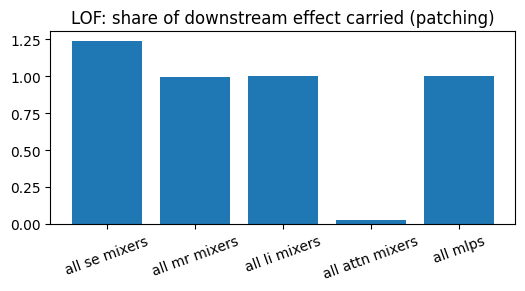


===== FUNC: chr17:41276135 T>G  lab score=-0.37  Evo 2 delta-loglik=+0.00025
target run=-244.644  source run=-244.396  difference=+0.248
  L4  se   mixer         restores +245.1%   (metric -244.035)
  L26 mr   mixer         restores -241.2%   (metric -245.243)
  L5  mr   mixer         restores +223.4%   (metric -244.089)
  L26 mr   mlp           restores -223.3%   (metric -245.199)
  L0  se   mlp           restores +208.7%   (metric -244.126)
  L27 li   mixer         restores +204.2%   (metric -244.137)
  L7  se   mixer         restores +202.5%   (metric -244.141)
  L6  li   mlp           restores +201.1%   (metric -244.145)
  L4  se   mlp           restores -170.8%   (metric -245.068)
  L7  se   mlp           restores +162.8%   (metric -244.240)
direct effect on next letter, alt - ref: {'embed': -0.0, 'se': 0.0, 'mlp': 0.0, 'mr': -0.0, 'li': -0.374, 'attn': -0.0}


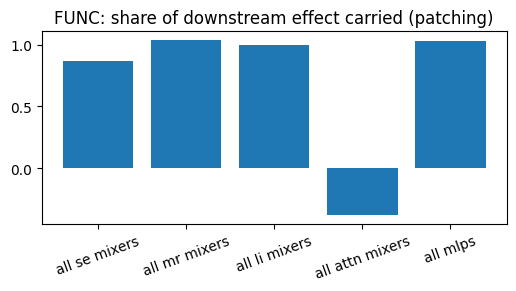

In [17]:
WINDOW = 8192
picks = {'LOF': brca1[brca1['func.class'] == 'LOF'].iloc[0], 'FUNC': brca1[brca1['func.class'] == 'FUNC'].iloc[0]}
RESULTS['brca1'] = {}
for label, row in picks.items():
    pos = int(row['position (hg19)']) - 1            # 0-based
    v = mh.make_variant(chr17, pos, row['reference'], row['alt'], window=WINDOW)
    dl = mh.delta_logp(hm, v)
    print(f"\n===== {label}: chr17:{pos+1} {row['reference']}>{row['alt']}  lab score={row['function.score.mean']:.2f}"
          f"  Evo 2 delta-loglik={dl:+.5f}")
    sweep = mh.explain_variant(hm, v, span=200)
    sweep.show(k=10)
    groups = {r.component: r.fraction for r in sweep.results if isinstance(r.component, str)}
    nxt = v.index + 1
    dref = mh.decompose_prediction(hm, v.ref_window, nxt, target=v.ref_window[nxt]).by_kind()
    dalt = mh.decompose_prediction(hm, v.alt_window, nxt, target=v.ref_window[nxt]).by_kind()
    print('direct effect on next letter, alt - ref:', {k: round(dalt[k] - dref[k], 3) for k in dref})
    RESULTS['brca1'][label] = {'pos': pos + 1, 'ref': row['reference'], 'alt': row['alt'], 'delta_logp': dl,
                               'group_restoration': groups}
    plt.figure(figsize=(6, 2.5))
    plt.bar(list(groups), list(groups.values()))
    plt.title(f'{label}: share of downstream effect carried (patching)'); plt.xticks(rotation=20); plt.show()

## 9. OPTIONAL: SAE features by operator type

The public Goodfire SAE reads block 26 of **`evo2_7b_262k`** (a different checkpoint), so this section swaps models.
For the strongest features on a stretch of E. coli DNA, it shows which operator types build them (an exact direct-effect
split of the SAE encoder input).

In [18]:
RUN_SAE = False
if RUN_SAE:
    import gc
    from marv_hyena import sae as sae_mod
    del hm; gc.collect(); torch.cuda.empty_cache()
    hm = mh.HyenaModel.load(sae_mod.SAE_MODEL)
    sae = sae_mod.load_goodfire_sae(device=hm.device)
    s2 = genome[100_000:102_048]
    acts = sae_mod.feature_acts(hm, sae, s2)
    top_feats = acts.max(0).values.topk(5).indices.tolist()
    RESULTS['sae'] = []
    for f in top_feats:
        pos = int(acts[:, f].argmax())
        dec = sae_mod.decompose_feature(hm, sae, s2, pos, f)
        print(f'feature {f} @ {pos}: actual={dec.actual:+.3f}',
              {k: round(v, 3) for k, v in sorted(dec.by_kind().items())})
        RESULTS['sae'].append({'feature': f, 'position': pos, 'by_kind': dec.by_kind()})

## 10. Save results

This writes `results.json` (to Drive if mounted, otherwise download it from the file browser). Then append the outcomes
under each prediction in `PREDICTIONS.md`, without editing the predictions themselves.

In [19]:
import json
out = '/content/drive/MyDrive/marv_hyena_results.json' if USE_DRIVE else 'results.json'
with open(out, 'w') as f:
    json.dump(RESULTS, f, indent=1, default=float)
print('wrote', out)

wrote results.json
